# Birth-Death Processes

A **birth-death process** is a continuous-time Markov chain on the states `0, 1, 2, ...` that can only step **up by one** ("a birth") or **down by one** ("a death") at a time. From state `n` it moves to `n + 1` at the *birth rate* and to `n - 1` at the *death rate*. Each draw is a sample path -- a function of continuous time giving the count at each moment.

In [1]:
from symbulate import *

## Create a process and draw a path

Each draw is a step function of continuous time. Evaluate it at any time `t` to get the count at that moment.

In [2]:
X = BirthDeathProcess(birth_rates=1, death_rates=1.2, num_states=31)
path = X.draw()
[path(t) for t in [0, 1, 2, 5, 10]]

[0, 0, 0, 2, 1]

## Simulate and plot sample paths

Simulate the process like any other Symbulate random variable, and plot the paths over a time range.

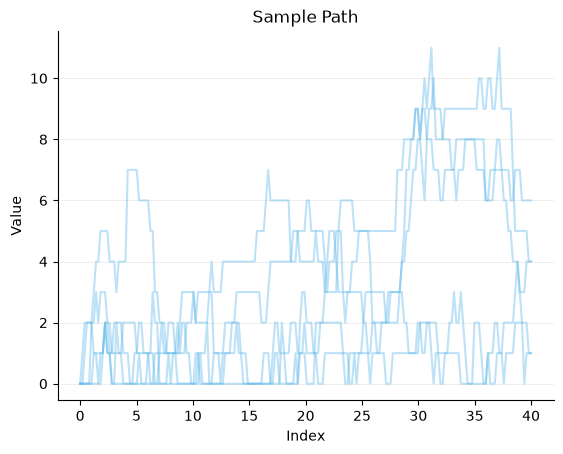

In [3]:
X.sim(5).plot(tmin=0, tmax=40)

## Rates that depend on the state

Instead of a constant, pass a **function of the state** (or a list with one rate per state). Here births happen at a constant rate 2, while deaths speed up the more individuals are present (`death_rate(n) = 0.5 * n`), which pulls the count back down as it grows.

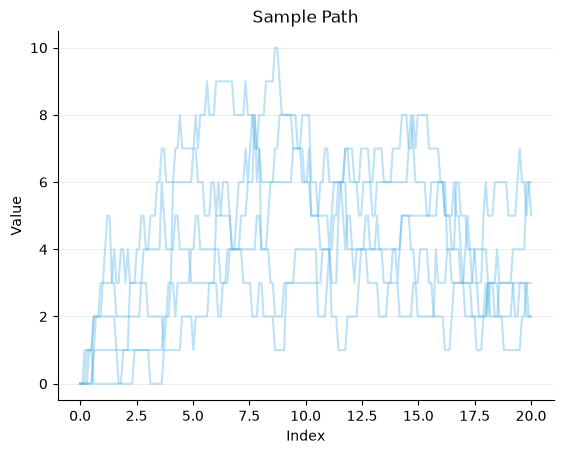

In [4]:
Y = BirthDeathProcess(birth_rates=2, death_rates=lambda n: 0.5 * n, num_states=31)
Y.sim(5).plot(tmin=0, tmax=20)

## Choose the starting state

By default the process starts at 0. Use `initial` to start somewhere else.

In [5]:
Z = BirthDeathProcess(birth_rates=1, death_rates=1.5, num_states=31, initial=10)
Z.draw()(0)

10

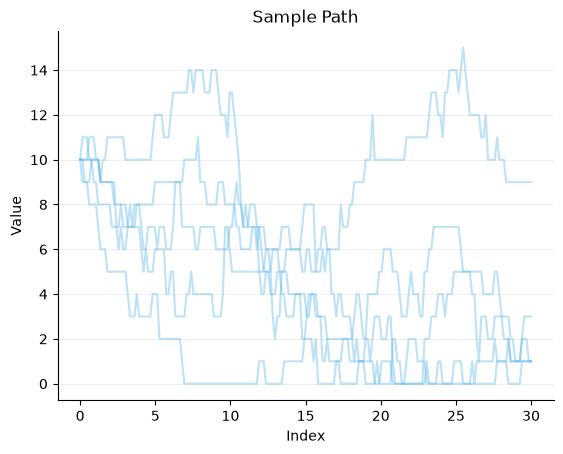

In [6]:
Z.sim(5).plot(tmin=0, tmax=30)

## The count at a fixed time

The count at a particular time is itself a random variable. Index the process at a time, `X[t]`, to get it -- then simulate, plot, or summarize it like any other random variable.

Currently Showing: Impulse Plot (Default)
Alternative Plots: Histogram (type = "hist"), Dot Plot (type = "dotplot"), ECDF Plot (type = "ecdf")


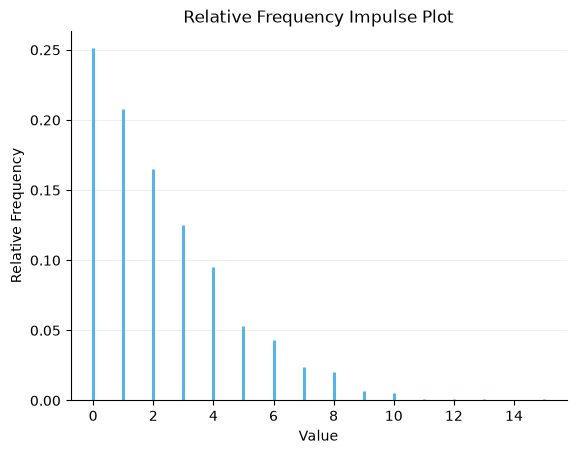

In [7]:
X[10].sim(1000).plot()

In [8]:
X[10].sim(1000).mean()

2.372